### ＡIプログラミング2 9,10回目<br>

# 1.手書き文字(MNIST)の読み込み

###(1)データの読み込み(MNISTを読み込む)

In [1]:
from torchvision.datasets import MNIST
from torchvision import transforms

img_size = 28  # 画像の高さと幅

# 訓練データを取得
mnist_train = MNIST("./data",
                    train=True, download=True,
                    transform=transforms.ToTensor())  # Tensorに変換
# テストデータの取得
mnist_test = MNIST("./data",
                   train=False, download=True,
                   transform=transforms.ToTensor())  # Tensorに変換

print("訓練データの数:", len(mnist_train), "テストデータの数:", len(mnist_test))

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 16280526.69it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 528360.79it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 3796725.63it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 4268547.79it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

訓練データの数: 60000 テストデータの数: 10000


In [ ]:
print("訓練データの数:", len(mnist_train), "テストデータの数:", len(mnist_test))
print("訓練データの数:", type(mnist_train[0][0][0]),mnist_train[0][0][0])

訓練データの数: 60000 テストデータの数: 10000
訓練データの数: <class 'torch.Tensor'> tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 

###(2)データローダの設定

In [2]:
from torch.utils.data import DataLoader

# DataLoaderの設定
batch_size = 256  # バッチサイズ
train_loader = DataLoader(mnist_train,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(mnist_test,
                         batch_size=batch_size,
                         shuffle=False)

###(3)モデルの構築

In [ ]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(img_size*img_size, 1024)  # 全結合層
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 10)
        self.relu = nn.ReLU()  # ReLU 学習するパラメータがないので使い回しできる

#forwardが重要(pytorchでは)
    def forward(self, x):
        x = x.view(-1, img_size*img_size)  # (バッチサイズ, 入力の数): 画像を1次元に変換
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()
net.cuda()  # GPU対応
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)


### (4)ミニバッチによるモデルの学習

In [ ]:
from torch import optim
# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()
# SGD
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(8):  # 8エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)

Epoch: 0 Loss_Train: 2.216201995281463 Loss_Test: 2.089206171035767
Epoch: 1 Loss_Train: 1.8293577239868488 Loss_Test: 1.4509757161140442
Epoch: 2 Loss_Train: 1.1274335747069502 Loss_Test: 0.8369216024875641
Epoch: 3 Loss_Train: 0.7287861339589383 Loss_Test: 0.6042532414197922
Epoch: 4 Loss_Train: 0.5701366287596682 Loss_Test: 0.49878043346107004
Epoch: 5 Loss_Train: 0.49030973467421024 Loss_Test: 0.43988284952938556
Epoch: 6 Loss_Train: 0.44233087225163237 Loss_Test: 0.40202461164444686
Epoch: 7 Loss_Train: 0.4099428057670593 Loss_Test: 0.3759996106848121


###(5)誤差をグラフに

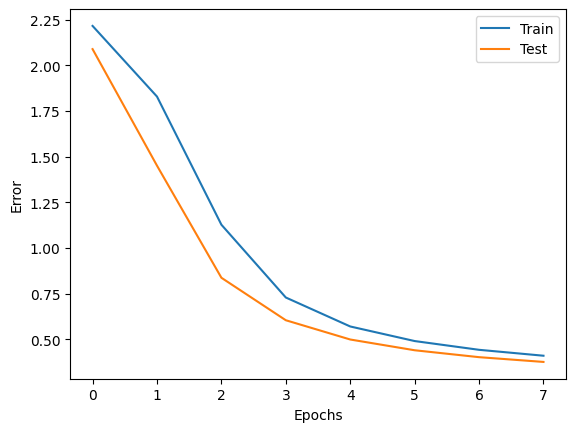

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

###(6)正解率(精度)の計算

In [ ]:
count = 0
total = 0
net.eval()  # 評価モード

#ミニバッチ分取り出す
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)    #まとめて予測

    #予測1つずつを正解と比較
    for j, y_j in enumerate(y):
      y_label=y_j.argmax().item()
      t_label=t[j].item()

      #予測と正解ラベルが同じだったらカウントアップ
      if y_label ==t_label:
        count+=1

    total += len(x)  #miniバッチ分ごとに合計
print("正解率:", str(count/total))

正解率: 0.8952


#課題1<br>
ニューラルネットワークの構成を変更し、損失に変化や精度(正解率)について比較しなさい。<br>


Net1(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=10, bias=True)
  (relu): ReLU()
)
Epoch: 0 Loss_Train: 2.2882525667231133 Loss_Test: 2.2693988263607023
Epoch: 1 Loss_Train: 2.238310438521365 Loss_Test: 2.1863714814186097
Epoch: 2 Loss_Train: 2.065346208024532 Loss_Test: 1.852846297621727
Epoch: 3 Loss_Train: 1.5020436956527385 Loss_Test: 1.1163748666644095
Epoch: 4 Loss_Train: 0.9158516556658644 Loss_Test: 0.735038547962904
Epoch: 5 Loss_Train: 0.6664390671760478 Loss_Test: 0.574633515253663
Epoch: 6 Loss_Train: 0.5476123088217796 Loss_Test: 0.487356598675251
Epoch: 7 Loss_Train: 0.47823362705555367 Loss_Test: 0.43332098629325627
Epoch: 8 Loss_Train: 0.43320856576270245 Loss_Test: 0.3978273544460535
Epoch: 9 Loss_Train: 0.4024389736195828 Loss_Test: 0.3740168048068881


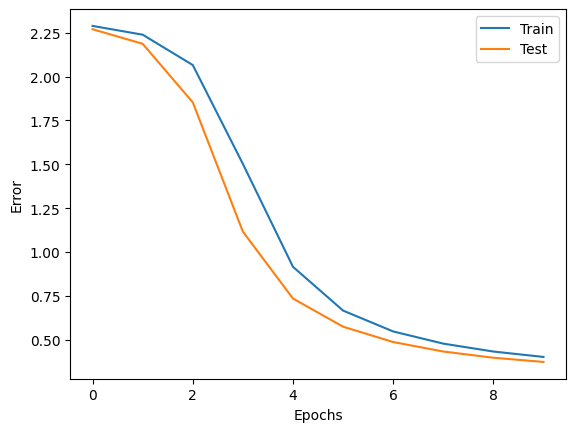

正解率: 0.8911


In [7]:
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(img_size*img_size, 1024)  # 全結合層
        self.fc2 = nn.Linear(1024, 512)
        self.fc4 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        self.relu = nn.ReLU()  # ReLU

#forwardが重要(pytorchでは)
    def forward(self, x):
        x = x.view(-1, img_size*img_size)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc4(x))
        x = self.fc3(x)
        return x

net = Net1()
net.cuda()  # GPU対応
print(net)


# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# SGD
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(10):  # 10エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)


#誤差のグラフ化

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

##正解率の計算
count = 0
total = 0
net.eval()  # 評価モード

#ミニバッチ分取り出す
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)    #まとめて予測

    #予測1つずつを正解と比較
    for j, y_j in enumerate(y):
      y_label=y_j.argmax().item()
      t_label=t[j].item()

      #予測と正解ラベルが同じだったらカウントアップ
      if y_label ==t_label:
        count+=1

    total += len(x)  #miniバッチ分ごとに合計
print("正解率:", str(count/total))


違うパターン

Net1(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=500, bias=True)
  (fc3): Linear(in_features=500, out_features=10, bias=True)
  (relu): ReLU()
)
Epoch: 0 Loss_Train: 2.2257151380498357 Loss_Test: 2.109981596469879
Epoch: 1 Loss_Train: 1.8655072430346875 Loss_Test: 1.5078667134046555
Epoch: 2 Loss_Train: 1.1761489482636147 Loss_Test: 0.8784886792302131
Epoch: 3 Loss_Train: 0.7552148803751519 Loss_Test: 0.6229442030191421
Epoch: 4 Loss_Train: 0.581389454070558 Loss_Test: 0.5071502376347781
Epoch: 5 Loss_Train: 0.49496330720313053 Loss_Test: 0.44332529678940774
Epoch: 6 Loss_Train: 0.4444888500457114 Loss_Test: 0.4034962709993124
Epoch: 7 Loss_Train: 0.41082081109919444 Loss_Test: 0.37712128534913064
Epoch: 8 Loss_Train: 0.38689091535324743 Loss_Test: 0.3579561397433281
Epoch: 9 Loss_Train: 0.3689868616930982 Loss_Test: 0.34264983544126154


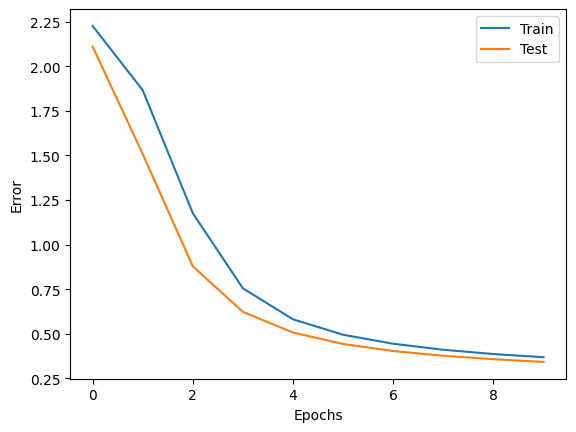

正解率: 0.9028


In [8]:
import torch.nn as nn
from torch import optim
import matplotlib.pyplot as plt

class Net1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(img_size*img_size, 1024)  # 全結合層
        self.fc2 = nn.Linear(1024, 500)
        self.fc3 = nn.Linear(500, 10)
        self.relu = nn.ReLU()  # ReLU

#forwardが重要(pytorchでは)
    def forward(self, x):
        x = x.view(-1, img_size*img_size)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net1()
net.cuda()  # GPU対応
print(net)


# 交差エントロピー誤差関数
loss_fnc = nn.CrossEntropyLoss()

# SGD
optimizer = optim.SGD(net.parameters(), lr=0.01)

# 損失のログ
record_loss_train = []
record_loss_test = []

# 学習
for i in range(10):  # 10エポック学習
    net.train()  # 訓練モード
    loss_train = 0
    for j, (x, t) in enumerate(train_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_train += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_train /= j+1
    record_loss_train.append(loss_train)

    net.eval()  # 評価モード
    loss_test = 0
    for j, (x, t) in enumerate(test_loader):  # ミニバッチ（x, t）を取り出す
        x, t = x.cuda(), t.cuda()  # GPU対応
        y = net(x)
        loss = loss_fnc(y, t)
        loss_test += loss.item()
    loss_test /= j+1
    record_loss_test.append(loss_test)

    if i%1 == 0:
        print("Epoch:", i, "Loss_Train:", loss_train, "Loss_Test:", loss_test)


#誤差のグラフ化

plt.plot(range(len(record_loss_train)), record_loss_train, label="Train")
plt.plot(range(len(record_loss_test)), record_loss_test, label="Test")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

##正解率の計算
count = 0
total = 0
net.eval()  # 評価モード

#ミニバッチ分取り出す
for i, (x, t) in enumerate(test_loader):
    x, t = x.cuda(), t.cuda()  # GPU対応
    y = net(x)    #まとめて予測

    #予測1つずつを正解と比較
    for j, y_j in enumerate(y):
      y_label=y_j.argmax().item()
      t_label=t[j].item()

      #予測と正解ラベルが同じだったらカウントアップ
      if y_label ==t_label:
        count+=1

    total += len(x)  #miniバッチ分ごとに合計
print("正解率:", str(count/total))
